# Module 1.2 — Python for CFD

**Why a dedicated Python module before the physics?**
Every CFD equation you write from Module 1.3 onward will be coded as a NumPy array operation. If the array indexing is wrong, the physics will be wrong — and the error won't announce itself. The solver will run, converge, and give you a beautiful but incorrect result.

This module builds the exact Python vocabulary you need so that later, when you are thinking about the physics, you are not simultaneously fighting the syntax.

**Roadmap:**
1. The CFD data model — why a field is just an array
2. Vectorisation — why loops are forbidden in CFD code
3. Array slicing as stencils — the core pattern you will use in every solver
4. Building and working with 2D grids
5. Essential visualisation patterns for CFD
6. Common mistakes and how to catch them

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

## 1. The CFD Data Model

### A field is just an array

In the real world, temperature exists as a continuous function $T(x, y, t)$ — a value at every point in space at every instant of time. In CFD, you represent this with a 3D array:

```python
T[j, i, n]   # temperature at cell (i,j) at time step n
```

The indices encode **location** and **time**. The value at each index is one number. Everything else in CFD is manipulating these numbers according to the physics.

### The index convention used throughout this curriculum

```
u[j, i]    →   velocity at column i (x direction), row j (y direction)
              ↑                 ↑
              axis 0            axis 1
              (y direction)     (x direction)

Physical picture:

  j=ny-1  ┌──────────────────┐
  j=ny-2  │  u[ny-2, :]      │   ← second row from top
    ...   │                  │
  j=1     │  u[1, :]         │   ← second row from bottom
  j=0     └──────────────────┘
           i=0  i=1  ... i=nx-1
```

**Why j first?** NumPy stores arrays in row-major order (C order). Row index is the outer loop, column index is the inner loop. Since y maps to rows and x to columns, $u[j, i]$ gives the point at $(x_i, y_j)$.

**Common mistake:** confusing $x$ and $y$ axes. If your flow goes the wrong direction or your contour plots are transposed, this is always the first thing to check.

In [6]:
# ── Why loops are forbidden — benchmark ─────────────────────────────────────
# The second-derivative stencil: d²u/dx² ≈ (u[i+1] - 2u[i] + u[i-1]) / dx²
# Applied at every interior point of a 500×500 grid.

N = 500
u = np.random.rand(N, N)
dx = 1.0 / N

# ── Loop version (what you might write first) ────────────────────────────────
t0 = time.perf_counter()
d2u_loop = np.zeros_like(u)
for j in range(1, N-1):
    for i in range(1, N-1):
        d2u_loop[j, i] = (u[j, i+1] - 2*u[j, i] + u[j, i-1]) / dx**2
t_loop = time.perf_counter() - t0

# ── Vectorised version (what you must write for CFD) ────────────────────────
# Replace the inner loops with array slicing.
# u[1:-1, 2:]  →  all interior rows, shifted one cell to the RIGHT  (= u[j, i+1])
# u[1:-1, 1:-1] →  all interior rows, centre cell                   (= u[j, i]  )
# u[1:-1, :-2] →  all interior rows, shifted one cell to the LEFT   (= u[j, i-1])
t0 = time.perf_counter()
d2u_vec = np.zeros_like(u)
d2u_vec[1:-1, 1:-1] = (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2]) / dx**2
t_vec = time.perf_counter() - t0

print(f'Loop version:       {t_loop*1000:.1f} ms')
print(f'Vectorised version: {t_vec*1000:.2f} ms')
print(f'Speedup:            {t_loop/t_vec:.0f}×')
print(f'Results identical:  {np.allclose(d2u_loop, d2u_vec)}   ← must be True')
print()
print('A 500-iteration CFD solve with loops would take:',
      f'{t_loop * 500:.1f} s')
print('A 500-iteration CFD solve vectorised takes:',
      f'{t_vec * 500:.2f} s')
print('Loop code is not wrong — it is just too slow for any real simulation.')

Loop version:       123.8 ms
Vectorised version: 1.04 ms
Speedup:            119×
Results identical:  True   ← must be True

A 500-iteration CFD solve with loops would take: 61.9 s
A 500-iteration CFD solve vectorised takes: 0.52 s
Loop code is not wrong — it is just too slow for any real simulation.


## 2. Array Slicing as Stencils — The Core Pattern

Every finite-difference formula involves a grid point and its neighbours. Array slicing implements this without loops.

### The shift table — know this by heart

For a 1D array `u` of length `N`:

| Python slice | Meaning | Finite-difference role |
|--------------|---------|------------------------|
| `u[1:-1]`    | All interior points | The point $u_i$ |
| `u[2:]`      | Shifted right by 1 | Right neighbour $u_{i+1}$ |
| `u[:-2]`     | Shifted left by 1 | Left neighbour $u_{i-1}$ |
| `u[3:]`      | Shifted right by 2 | $u_{i+2}$ |
| `u[:-3]`     | Shifted left by 2 | $u_{i-2}$ |

For a 2D array `u` of shape `(ny, nx)`:

| Expression | Grid neighbour |
|------------|----------------|
| `u[1:-1, 2:]`  | Right: $u_{j,i+1}$ |
| `u[1:-1, :-2]` | Left: $u_{j,i-1}$ |
| `u[2:, 1:-1]`  | Up: $u_{j+1,i}$ |
| `u[:-2, 1:-1]` | Down: $u_{j-1,i}$ |

### The three fundamental stencils

**First derivative — central difference** ($O(\Delta x^2)$):

$$\frac{\partial u}{\partial x}\bigg|_i \approx \frac{u_{i+1} - u_{i-1}}{2\Delta x}$$
```python
dudx[1:-1] = (u[2:] - u[:-2]) / (2*dx)
```

**First derivative — upwind** ($O(\Delta x)$, but stable for advection):

$$\frac{\partial u}{\partial x}\bigg|_i \approx \frac{u_i - u_{i-1}}{\Delta x} \quad (c > 0)$$
```python
dudx[1:] = (u[1:] - u[:-1]) / dx
```

**Second derivative — central** ($O(\Delta x^2)$):

$$\frac{\partial^2 u}{\partial x^2}\bigg|_i \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}$$
```python
d2udx2[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
```

This last stencil — `u[2:] - 2*u[1:-1] + u[:-2]` — appears in every diffusion equation, every pressure Poisson equation, and every implicit solver. Memorise it.

Central difference  du/dx:   max error = 1.05e-03  ← O(dx²) = 6.33e-03
Upwind  difference  du/dx:   max error = 3.98e-02   ← O(dx)  = 7.95e-02
Central difference d²u/dx²:  max error = 5.27e-04     ← O(dx²) = 6.33e-03

Central difference is more accurate than upwind because it uses
both neighbours symmetrically → cancels the O(dx) error term.


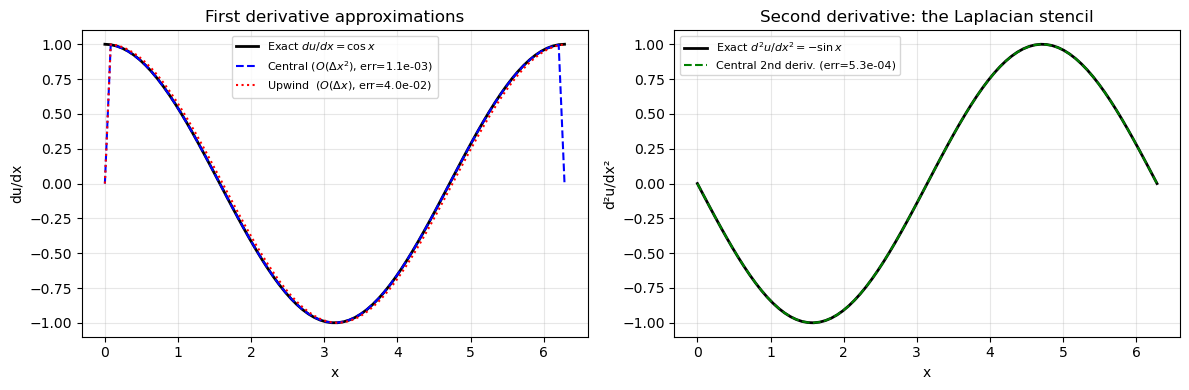

In [7]:
# ── Verify all three stencils on a known function ───────────────────────────
# Use u(x) = sin(x) → du/dx = cos(x) → d²u/dx² = -sin(x)

N  = 80
x  = np.linspace(0, 2*np.pi, N)
dx = x[1] - x[0]
u  = np.sin(x)

# ── Derivatives ─────────────────────────────────────────────────────────────
dudx_central = np.zeros(N)
dudx_central[1:-1] = (u[2:] - u[:-2]) / (2*dx)          # central: O(dx²)

dudx_upwind = np.zeros(N)
dudx_upwind[1:]    = (u[1:] - u[:-1]) / dx               # upwind: O(dx)

d2udx2 = np.zeros(N)
d2udx2[1:-1]       = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2  # central: O(dx²)

# ── Errors ──────────────────────────────────────────────────────────────────
err_central = np.max(np.abs(dudx_central[1:-1] - np.cos(x[1:-1])))
err_upwind  = np.max(np.abs(dudx_upwind[1:-1]  - np.cos(x[1:-1])))
err_2nd     = np.max(np.abs(d2udx2[1:-1]       - (-np.sin(x[1:-1]))))

print(f'Central difference  du/dx:   max error = {err_central:.2e}  ← O(dx²) = {dx**2:.2e}')
print(f'Upwind  difference  du/dx:   max error = {err_upwind:.2e}   ← O(dx)  = {dx:.2e}')
print(f'Central difference d²u/dx²:  max error = {err_2nd:.2e}     ← O(dx²) = {dx**2:.2e}')
print()
print('Central difference is more accurate than upwind because it uses')
print('both neighbours symmetrically → cancels the O(dx) error term.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, np.cos(x),          'k-',  lw=2,   label='Exact $du/dx = \\cos x$')
axes[0].plot(x, dudx_central, 'b--', lw=1.5, label=f'Central ($O(\\Delta x^2)$, err={err_central:.1e})')
axes[0].plot(x, dudx_upwind,  'r:',  lw=1.5, label=f'Upwind  ($O(\\Delta x)$, err={err_upwind:.1e})')
axes[0].set_xlabel('x'); axes[0].set_ylabel('du/dx')
axes[0].set_title('First derivative approximations'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, -np.sin(x), 'k-', lw=2, label='Exact $d^2u/dx^2 = -\\sin x$')
axes[1].plot(x, d2udx2, 'g--', lw=1.5, label=f'Central 2nd deriv. (err={err_2nd:.1e})')
axes[1].set_xlabel('x'); axes[1].set_ylabel('d²u/dx²')
axes[1].set_title('Second derivative: the Laplacian stencil')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Building and Working with 2D Grids

### The standard grid setup

Every 2D solver in this curriculum starts with this exact pattern:

```python
nx, ny = 50, 40          # number of cells in x, y
Lx, Ly = 2.0, 1.0       # domain size
dx     = Lx / nx
dy     = Ly / ny
x      = np.linspace(0.5*dx, Lx - 0.5*dx, nx)   # cell-CENTRE positions
y      = np.linspace(0.5*dy, Ly - 0.5*dy, ny)
X, Y   = np.meshgrid(x, y)                        # shape: (ny, nx)
```

**Cell centres vs. cell faces:** We place the grid points at cell centres, not at the faces. This is the **cell-centred FVM convention** used by OpenFOAM and Fluent. The domain goes from 0 to Lx, but the first cell centre is at $0.5\Delta x$, not at 0.

```
Face    Cell    Face    Cell    Face
  |  x[0]  |  x[1]  |  x[2]  |
  0   dx/2  dx  3dx/2  2dx  5dx/2
```

**Why cell centres?** Boundary conditions are applied at the faces. Cell-centre storage naturally gives second-order accuracy: the face is equidistant from both neighbouring centres, so linear interpolation between them is exact for any linear field.

### The 2D Laplacian — the most important 2D stencil

$$\nabla^2 u = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \approx \frac{u_{j,i+1}-2u_{j,i}+u_{j,i-1}}{\Delta x^2} + \frac{u_{j+1,i}-2u_{j,i}+u_{j-1,i}}{\Delta y^2}$$

```python
lap[1:-1, 1:-1] = (
    (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2]) / dx**2 +
    (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1]) / dy**2
)
```

This is the **five-point stencil** — the workhorse of 2D CFD. It appears in the pressure Poisson equation, heat conduction, and viscous terms.

Grid: 40×60,  dx=0.1047, dy=0.0785
Max error in 2D Laplacian: 1.424e-03
Expected O(dx²) error: ~ 1.097e-02
Ratio (error/dx²): 0.130   ← should be O(1)


TypeError: Shapes of x (40, 60) and z (38, 58) do not match

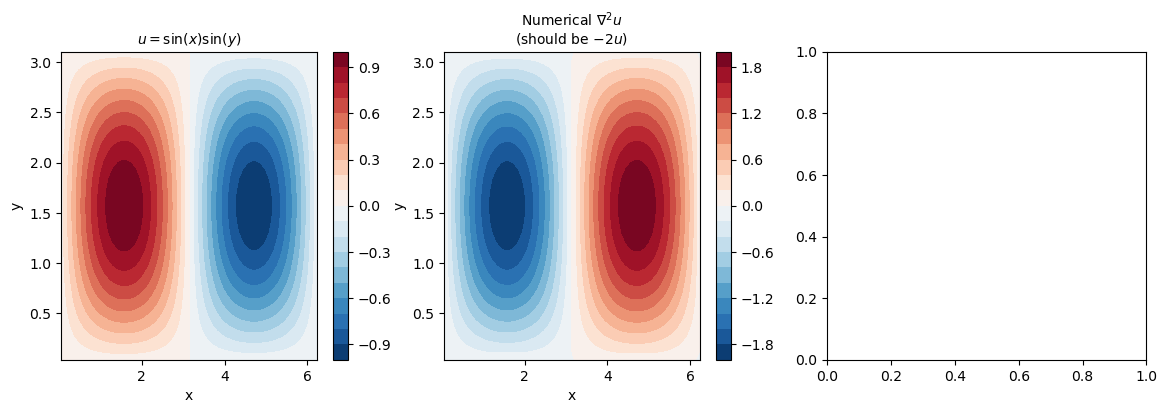

In [8]:
# ── 2D grid setup and the five-point Laplacian stencil ──────────────────────

# ── Grid ────────────────────────────────────────────────────────────────────
nx, ny = 60, 40
Lx, Ly = 2*np.pi, np.pi
dx = Lx / nx;  dy = Ly / ny
x  = np.linspace(0.5*dx, Lx - 0.5*dx, nx)
y  = np.linspace(0.5*dy, Ly - 0.5*dy, ny)
X, Y = np.meshgrid(x, y)   # shape: (ny, nx) = (40, 60)

# ── Test function: u = sin(x)·sin(y) ────────────────────────────────────────
# Exact Laplacian: ∇²u = -sin(x)sin(y) - sin(x)sin(y) = -2·sin(x)sin(y) = -2u
u     = np.sin(X) * np.sin(Y)
lap_exact = -2 * u

# ── Numerical 2D Laplacian (five-point stencil) ──────────────────────────────
lap_num = np.zeros_like(u)
lap_num[1:-1, 1:-1] = (
    (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2]) / dx**2 +   # d²u/dx²
    (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1]) / dy**2      # d²u/dy²
)

# ── Error ────────────────────────────────────────────────────────────────────
error = np.abs(lap_num[1:-1, 1:-1] - lap_exact[1:-1, 1:-1])
print(f'Grid: {ny}×{nx},  dx={dx:.4f}, dy={dy:.4f}')
print(f'Max error in 2D Laplacian: {error.max():.3e}')
print(f'Expected O(dx²) error: ~ {dx**2:.3e}')
print(f'Ratio (error/dx²): {error.max()/dx**2:.3f}   ← should be O(1)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, field, title in zip(axes,
    [u, lap_num, error],
    ['$u = \\sin(x)\\sin(y)$',
     'Numerical $\\nabla^2 u$\n(should be $-2u$)',
     '|Error| = |numerical − exact|']):
    cf = ax.contourf(X, Y, field, levels=20, cmap='RdBu_r')
    plt.colorbar(cf, ax=ax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Five-point Laplacian stencil — the core of 2D diffusion and Poisson solvers',
             fontsize=11)
plt.tight_layout()
plt.show()

## 4. Essential Visualisation Patterns

You will use these five plot types constantly. Learn them once and use them everywhere.

| Plot call | When to use | What it shows |
|-----------|-------------|---------------|
| `ax.contourf(X,Y,field)` | Scalar fields (p, T, speed) | Filled colour map |
| `ax.contour(X,Y,field)` | Scalar fields (streamfunction) | Iso-contour lines |
| `ax.streamplot(X,Y,U,V)` | 2D velocity field | Smooth streamlines |
| `ax.quiver(X,Y,U,V)` | Sparse velocity arrows | Direction + magnitude vectors |
| `ax.semilogy(iters, res)` | Convergence history | Residuals spanning many decades |

### The most important visualisation rule

**Always use `ax.set_aspect('equal')`** for flow field plots. Distorted aspect ratios make a circular vortex look elliptical — a physically wrong picture that leads to wrong intuition.

In [ ]:
# ── The five essential CFD visualisation patterns ───────────────────────────
# Using a Taylor-Green vortex: u = sin(x)cos(y), v = -cos(x)sin(y)
# This is an exact incompressible solution (div u = 0 everywhere)

nx, ny = 40, 40
x  = np.linspace(0, 2*np.pi, nx, endpoint=False)
y  = np.linspace(0, 2*np.pi, ny, endpoint=False)
X, Y = np.meshgrid(x, y)

U    =  np.sin(X) * np.cos(Y)
V    = -np.cos(X) * np.sin(Y)
speed = np.sqrt(U**2 + V**2)
pressure = -(np.cos(2*X) + np.cos(2*Y)) / 4   # exact pressure for TG vortex
psi  = np.sin(X) * np.sin(Y)                   # streamfunction

# Convergence history (simulated)
iters    = np.arange(1, 201)
residual = 1.0 * np.exp(-iters * 0.04) * (1 + 0.05*np.random.randn(200))
residual = np.maximum(residual, 1e-8)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# (1) Filled scalar field
cf = axes[0,0].contourf(X, Y, speed, levels=20, cmap='viridis')
plt.colorbar(cf, ax=axes[0,0], label='speed |u|')
axes[0,0].set_aspect('equal')
axes[0,0].set_title('contourf — scalar speed field', fontsize=10)
axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('y')

# (2) Iso-contour lines
axes[0,1].contour(X, Y, psi, levels=20, colors='royalblue', linewidths=1.2)
axes[0,1].set_aspect('equal')
axes[0,1].set_title('contour — streamlines (ψ = const)', fontsize=10)
axes[0,1].set_xlabel('x')

# (3) Streamplot
axes[0,2].streamplot(X, Y, U, V, color=speed, cmap='plasma',
                     linewidth=1.5, density=1.2)
axes[0,2].set_aspect('equal')
axes[0,2].set_title('streamplot — velocity streamlines', fontsize=10)
axes[0,2].set_xlabel('x')

# (4) Quiver plot
skip = 3
axes[1,0].quiver(X[::skip,::skip], Y[::skip,::skip],
                 U[::skip,::skip], V[::skip,::skip],
                 speed[::skip,::skip], cmap='coolwarm')
axes[1,0].set_aspect('equal')
axes[1,0].set_title('quiver — velocity arrows', fontsize=10)
axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('y')

# (5) Pressure contourf
cf2 = axes[1,1].contourf(X, Y, pressure, levels=20, cmap='RdBu_r')
plt.colorbar(cf2, ax=axes[1,1], label='pressure')
axes[1,1].set_aspect('equal')
axes[1,1].set_title('contourf — pressure field', fontsize=10)
axes[1,1].set_xlabel('x')

# (6) Convergence history
axes[1,2].semilogy(iters, residual, 'b-', linewidth=1.5)
axes[1,2].axhline(1e-6, color='r', linestyle='--', label='Convergence criterion $10^{-6}$')
conv_i = iters[residual < 1e-6][0]
axes[1,2].axvline(conv_i, color='g', linestyle=':', label=f'Converged at iter {conv_i}')
axes[1,2].set_xlabel('Iteration'); axes[1,2].set_ylabel('Residual')
axes[1,2].set_title('semilogy — convergence history', fontsize=10)
axes[1,2].legend(fontsize=8); axes[1,2].grid(True, which='both', alpha=0.3)

plt.suptitle('The five essential CFD visualisation patterns', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Common Mistakes and How to Catch Them

### Mistake 1 — Off-by-one boundary errors

The interior stencil `u[1:-1, 1:-1]` leaves the boundary rows/columns at their initial value (usually zero). If you forget to set boundary conditions **after** the interior update, the boundaries will be wrong and the solver will diverge.

**Rule:** Every time step, update interior → apply BCs. Never skip the BC step.

### Mistake 2 — Shape mismatch

The two divergence slices `u[1:-1, 2:] - u[1:-1, :-2]` give shape `(ny-2, nx-2)`. If you mix forward-difference slices with central-difference slices, the shapes won't match and you get a `ValueError`. Always write out the shapes of every slice when debugging.

### Mistake 3 — In-place modification during stencil update

```python
# WRONG — u[j] is modified before u[j+1] can read the old u[j]
u[1:-1] = u[1:-1] + dt * (u[2:] - 2*u[1:-1] + u[:-2])
```

Wait — this is actually safe for explicit time-stepping because NumPy evaluates the right side completely before assigning. But in a Gauss-Seidel iteration (implicit, sequential updates), you **must** copy first:

```python
u_old = u.copy()   # always copy before a loop that reads old values
```

### Mistake 4 — Using `np.trapz` (removed in NumPy 2.0)

Use `np.trapezoid` instead. You will see both in old code; only the new name works with NumPy ≥ 2.0.

## Summary

| Concept | Key rule |
|---------|----------|
| Indexing | `u[j, i]` → row = y, column = x |
| Vectorisation | No nested loops in the inner solver — always array slices |
| Central-diff 1st deriv | `(u[2:] - u[:-2]) / (2*dx)` → $O(\Delta x^2)$ |
| Laplacian stencil | `u[2:]-2*u[1:-1]+u[:-2]` in x plus same in y |
| Grid | Cell-centre positions: `linspace(0.5*dx, L-0.5*dx, N)` |
| After every update | Apply boundary conditions before the next time step |
| Always verify | Print the shape of every new array; run a known-answer test |

---
**Next:** Module 1.3 — Conservation Laws: mass, momentum, energy, and the Reynolds Transport Theorem that links them all.

## Exercise

**Predict first, then code.**

1. For $u(x) = e^{-x^2}$ on $x \in [-3, 3]$ with $N=100$: what is the exact second derivative at $x=0$? (Hint: differentiate $e^{-x^2}$ twice.)

2. Compute it numerically using the stencil `(u[2:] - 2*u[1:-1] + u[:-2]) / dx**2`. How close is your answer to the exact value at $x=0$?

3. Repeat with $N = 200$. By what factor does the error change? Does it match the $O(\Delta x^2)$ prediction?